In [1]:
import pandas as pd
import numpy as np

from visualization_utils import *
from simulation import methods, who
from simulation_utils import *

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Functions and Prep

In [3]:
countries = [
    {'country': 'Italy',
     'start_date': '2020-02-23', 
     'end_date' : '2023-10-30'},

    {'country': 'United Kingdom of Great Britain and Northern Ireland',
     'start_date': '2020-03-10', 
     'end_date' : '2023-10-22'},

    {'country': 'Israel',
     'start_date': '2020-03-25', 
     'end_date' : '2023-10-29'}
]

In [4]:
def summarize_performance(
    csv_path,
    cmap: str = "RdYlGn_r",
    lower_quantile: float = 0.05,
    upper_quantile: float = 0.95
):
    df = pd.read_csv(csv_path)
    df = df[df["method"] != "spline"]
    
    pivot = df.pivot(index="method", columns="missing", values="median")
    
    vals = pivot.to_numpy().flatten()
    vmin = np.nanquantile(vals, lower_quantile)
    vmax = np.nanquantile(vals, upper_quantile)
    
    styled = (
        pivot.style
             .background_gradient(
                 cmap=cmap,
                 axis=0,
                 vmin=vmin,
                 vmax=vmax
             )
             .set_caption("Median Performance by Method and Missing Percentage")
             .format("{:.2f}")
    )
    return styled


In [5]:
def load_method_metrics(path, methods: list[str], metrics: list[str],
) -> pd.DataFrame:
    """
    Load a CSV like 
      results/covid_MAR/{metric_name}/{country}_{n_cases}_cases_{metric_name}_results.csv
    and return a pivoted DataFrame of the requested methods & metrics.

    Parameters
    ----------
    country : str
        e.g. "Italy"
    n_cases : int
        e.g. 500
    metric_name : str
        e.g. "mape", "rmse"
    methods : list of str
        which methods to include, e.g. ['rmean','last','linear_interp', …]
    metrics : list of str
        which columns to pull, e.g. ['mean','std','min','max','median']
    root_dir : str
        base results folder (default "results")
    scenario : str
        subfolder for your experiment, e.g. "covid_MAR"

    Returns
    -------
    pd.DataFrame
        index = methods (in the order you passed them),
        columns = MultiIndex(metric, missing),
        values = the corresponding numbers
    """
 
    df = pd.read_csv(path)
    df = df[df['missing'] == 0.15]
    df = df[df["method"].isin(methods)]

    pivot = df.pivot(index="method", columns="missing", values=metrics)

    pivot = pivot.reindex(methods)

    pivot = pivot.sort_index(axis=1, level=1)

    pivot['range'] = pivot['max'] - pivot['min']

    return pivot


In [6]:
def show_results_detailed(missing_nature = "MCAR"):
    for country in countries:
        name = country['country']
        print(f"Results for {name}")
        path = f"results/covid_{missing_nature}/mape/{name}_500_cases_mape_results.csv"
        styled_table = summarize_performance(path)
        display(styled_table)

In [36]:
def show_results_aggregated(countries, missing_nature):
    all_results = []

    for country in countries:
        name = country['country']
        country_results = load_method_metrics(
            f"results/covid_{missing_nature}/mape/{name}_500_cases_mape_results.csv",
            ['knn', 'kalman', 'linear_interp', 'quadratic_interp'],
            ['median', 'max', 'min']
        )
                
        all_results.append(country_results)

    all_results_df = pd.concat(all_results)

    average_results = all_results_df.groupby(['method']).mean()

    print("Aggregated Results across all countries:")
    display(average_results)



In [37]:
natures = ["MCAR", "MAR", "MNAR"]

# Detailed Results

In [38]:
for nature in natures:
    print(f"Detailed results for {nature}")
    show_results_detailed(missing_nature = "MCAR")


Detailed results for MCAR
Results for Italy


missing,0.010000,0.050000,0.100000,0.150000,0.200000,0.250000
method,,,,,,
arima,0.31,0.33,0.33,0.33,0.33,0.32
kalman,0.29,0.30,0.31,0.31,0.31,0.31
knn,0.27,0.28,0.29,0.29,0.29,0.30
last,0.30,0.30,0.31,0.32,0.32,0.33
linear_interp,0.28,0.29,0.29,0.30,0.30,0.31
matrix_estimation,0.28,0.30,0.31,0.32,0.33,0.34
next,0.38,0.40,0.40,0.41,0.41,0.42
quadratic_interp,0.32,0.35,0.36,0.37,0.38,0.38
rmean,0.32,0.33,0.36,0.47,0.69,0.95


Results for United Kingdom of Great Britain and Northern Ireland


missing,0.010000,0.050000,0.100000,0.150000,0.200000,0.250000
method,,,,,,
arima,0.11,0.12,0.12,0.12,0.12,0.12
kalman,0.10,0.10,0.11,0.11,0.12,0.13
knn,0.10,0.11,0.11,0.12,0.12,0.13
last,0.14,0.15,0.15,0.16,0.16,0.16
linear_interp,0.09,0.09,0.10,0.10,0.11,0.11
matrix_estimation,0.13,0.13,0.14,0.14,0.14,0.15
next,0.14,0.15,0.16,0.16,0.17,0.17
quadratic_interp,0.08,0.09,0.10,0.10,0.11,0.11
rmean,0.17,0.18,0.19,0.28,0.41,0.51


Results for Israel


...

missing,0.010000,0.050000,0.100000,0.150000,0.200000,0.250000
method,,,,,,
arima,0.31,0.33,0.33,0.33,0.33,0.32
kalman,0.29,0.30,0.31,0.31,0.31,0.31
knn,0.27,0.28,0.29,0.29,0.29,0.30
last,0.30,0.30,0.31,0.32,0.32,0.33
linear_interp,0.28,0.29,0.29,0.30,0.30,0.31
matrix_estimation,0.28,0.30,0.31,0.32,0.33,0.34
next,0.38,0.40,0.40,0.41,0.41,0.42
quadratic_interp,0.32,0.35,0.36,0.37,0.38,0.38
rmean,0.32,0.33,0.36,0.47,0.69,0.95


Results for United Kingdom of Great Britain and Northern Ireland


missing,0.010000,0.050000,0.100000,0.150000,0.200000,0.250000
method,,,,,,
arima,0.11,0.12,0.12,0.12,0.12,0.12
kalman,0.10,0.10,0.11,0.11,0.12,0.13
knn,0.10,0.11,0.11,0.12,0.12,0.13
last,0.14,0.15,0.15,0.16,0.16,0.16
linear_interp,0.09,0.09,0.10,0.10,0.11,0.11
matrix_estimation,0.13,0.13,0.14,0.14,0.14,0.15
next,0.14,0.15,0.16,0.16,0.17,0.17
quadratic_interp,0.08,0.09,0.10,0.10,0.11,0.11
rmean,0.17,0.18,0.19,0.28,0.41,0.51


Results for Israel


missing,0.010000,0.050000,0.100000,0.150000,0.200000,0.250000
method,,,,,,
arima,0.31,0.35,0.35,0.36,0.36,0.36
kalman,0.26,0.28,0.28,0.29,0.29,0.30
knn,0.27,0.28,0.29,0.30,0.30,0.31
last,0.32,0.34,0.35,0.35,0.36,0.36
linear_interp,0.25,0.27,0.28,0.28,0.29,0.29
matrix_estimation,0.28,0.30,0.32,0.33,0.34,0.35
next,0.33,0.34,0.35,0.36,0.37,0.37
quadratic_interp,0.25,0.28,0.30,0.31,0.32,0.33
rmean,0.35,0.37,0.40,0.55,0.77,1.14


# Aggregated Results

In [39]:
for nature in natures:
    print(f"AGGREGATED RESULTS FOR {nature}")
    show_results_aggregated([i for i in countries], missing_nature=nature)

AGGREGATED RESULTS FOR MCAR
Aggregated Results across all countries:


,max,median,min,range
missing,0.15,0.15,0.15,
method,,,,
kalman,0.319505,0.237287,0.170571,0.148935
knn,0.330188,0.235848,0.168182,0.162005
linear_interp,0.322761,0.228262,0.165465,0.157297
quadratic_interp,4.085551,0.258780,0.186284,3.899266


AGGREGATED RESULTS FOR MAR
Aggregated Results across all countries:


,max,median,min,range
missing,0.15,0.15,0.15,
method,,,,
kalman,0.316506,0.239353,0.165614,0.150893
knn,0.326492,0.238285,0.165906,0.160586
linear_interp,0.314198,0.229355,0.161855,0.152343
quadratic_interp,3.775317,0.261963,0.187457,3.587860


AGGREGATED RESULTS FOR MNAR
Aggregated Results across all countries:


,max,median,min,range
missing,0.15,0.15,0.15,
method,,,,
kalman,0.387960,0.326965,0.278579,0.109381
knn,0.398079,0.335065,0.282696,0.115382
linear_interp,0.385785,0.324508,0.275562,0.110224
quadratic_interp,0.430246,0.323091,0.271118,0.159128


# Visualization

In [40]:
countries_data = {}
for country in countries:
    countries_data[country['country']] = get_country_series(who, country['country'], country['start_date'], country['end_date'])
    

## Countries Series Vizualizations

(<Figure size 1200x900 with 3 Axes>,
 array([<Axes: title={'center': 'New COVID-19 Cases in Italy'}, ylabel='New Cases'>,
        <Axes: title={'center': 'New COVID-19 Cases in United Kingdom of Great Britain and Northern Ireland'}, ylabel='New Cases'>,
        <Axes: title={'center': 'New COVID-19 Cases in Israel'}, xlabel='Date', ylabel='New Cases'>],
       dtype=object))

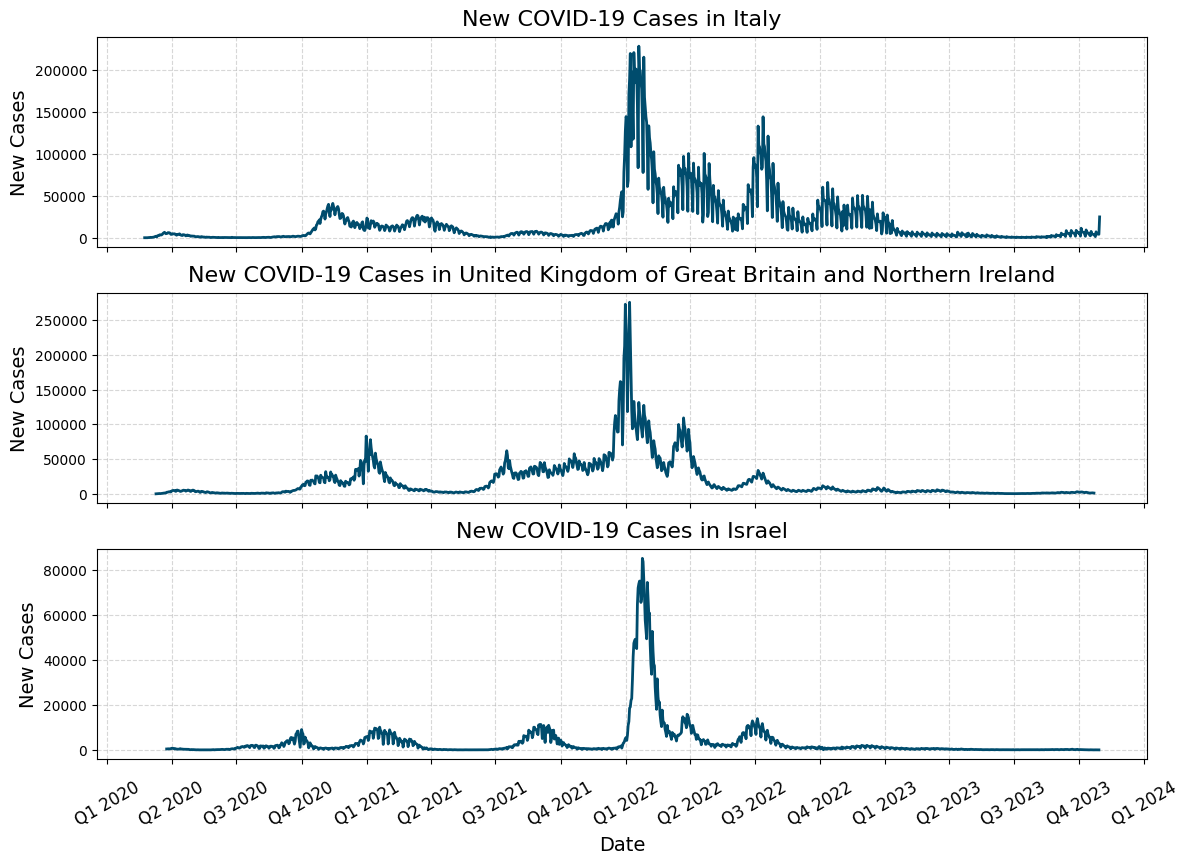

In [41]:
plot_countries_time_series(
    countries_data,
    figsize_per_plot=(12, 3),
    line_color='#004c6d',
    line_width=2)

## Performance Example Vizualizaion

THE MCAR NATURE


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/pytho

THE MAR NATURE


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/pytho

THE MNAR NATURE


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/pytho

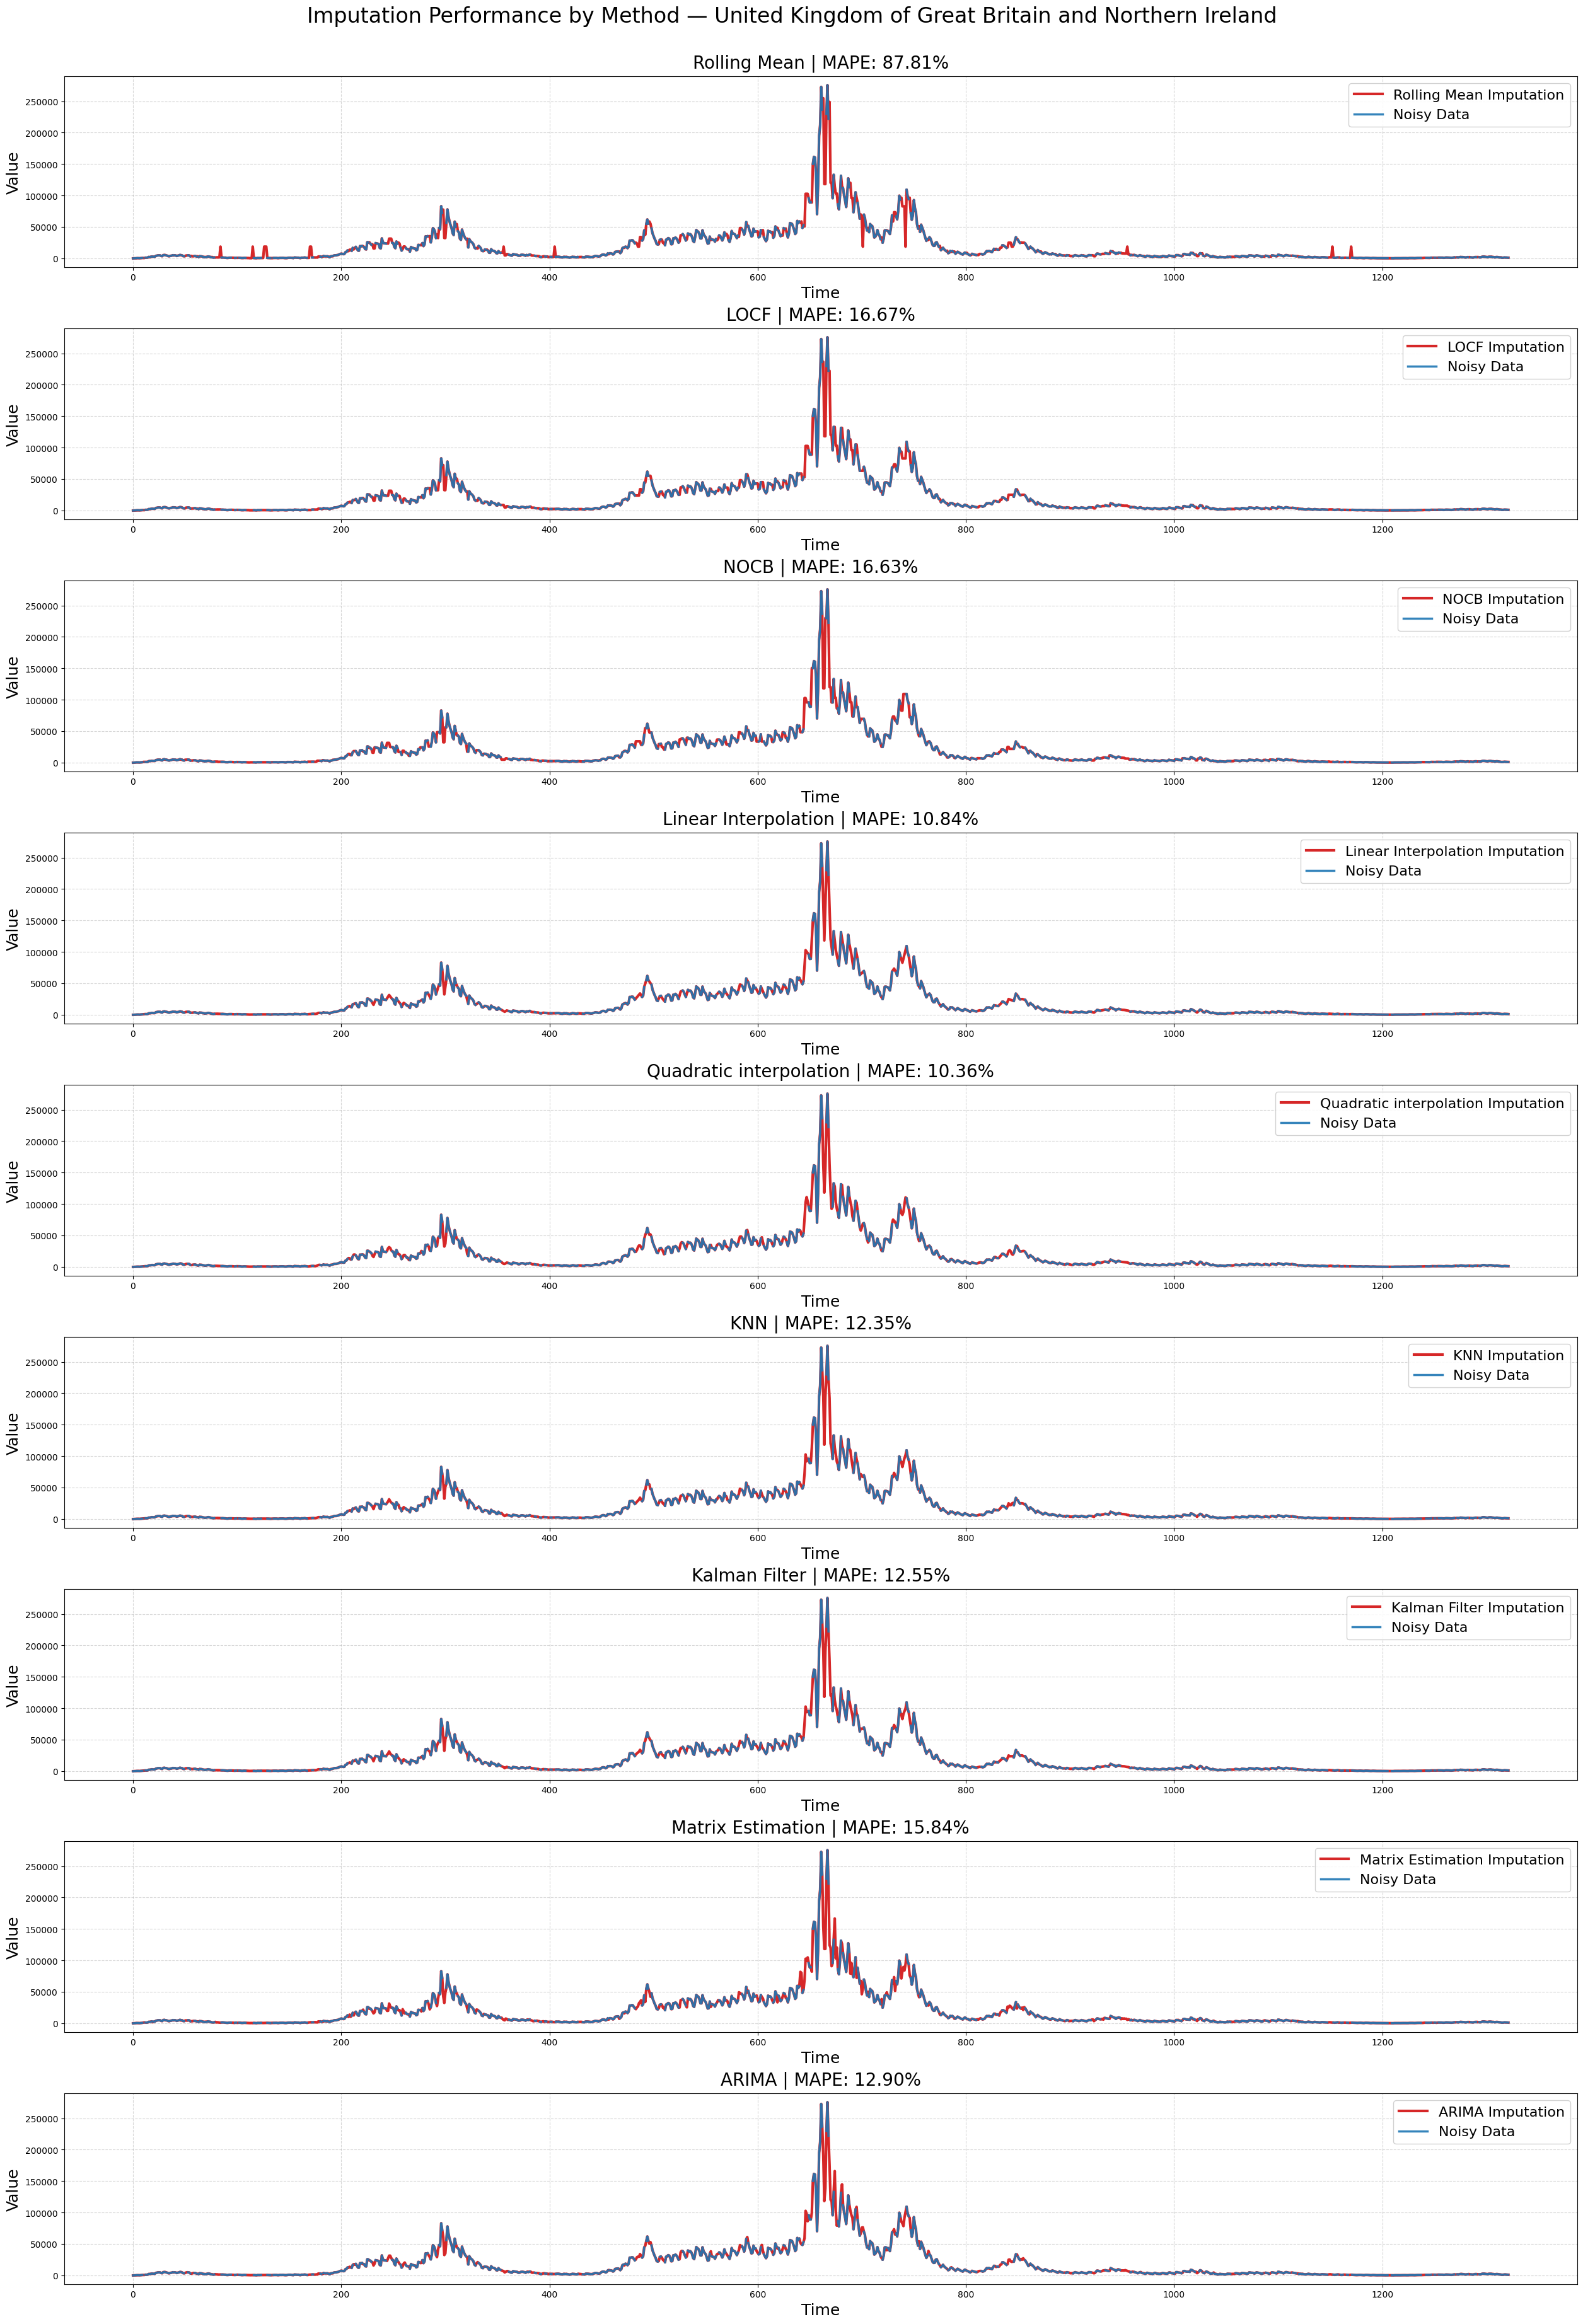

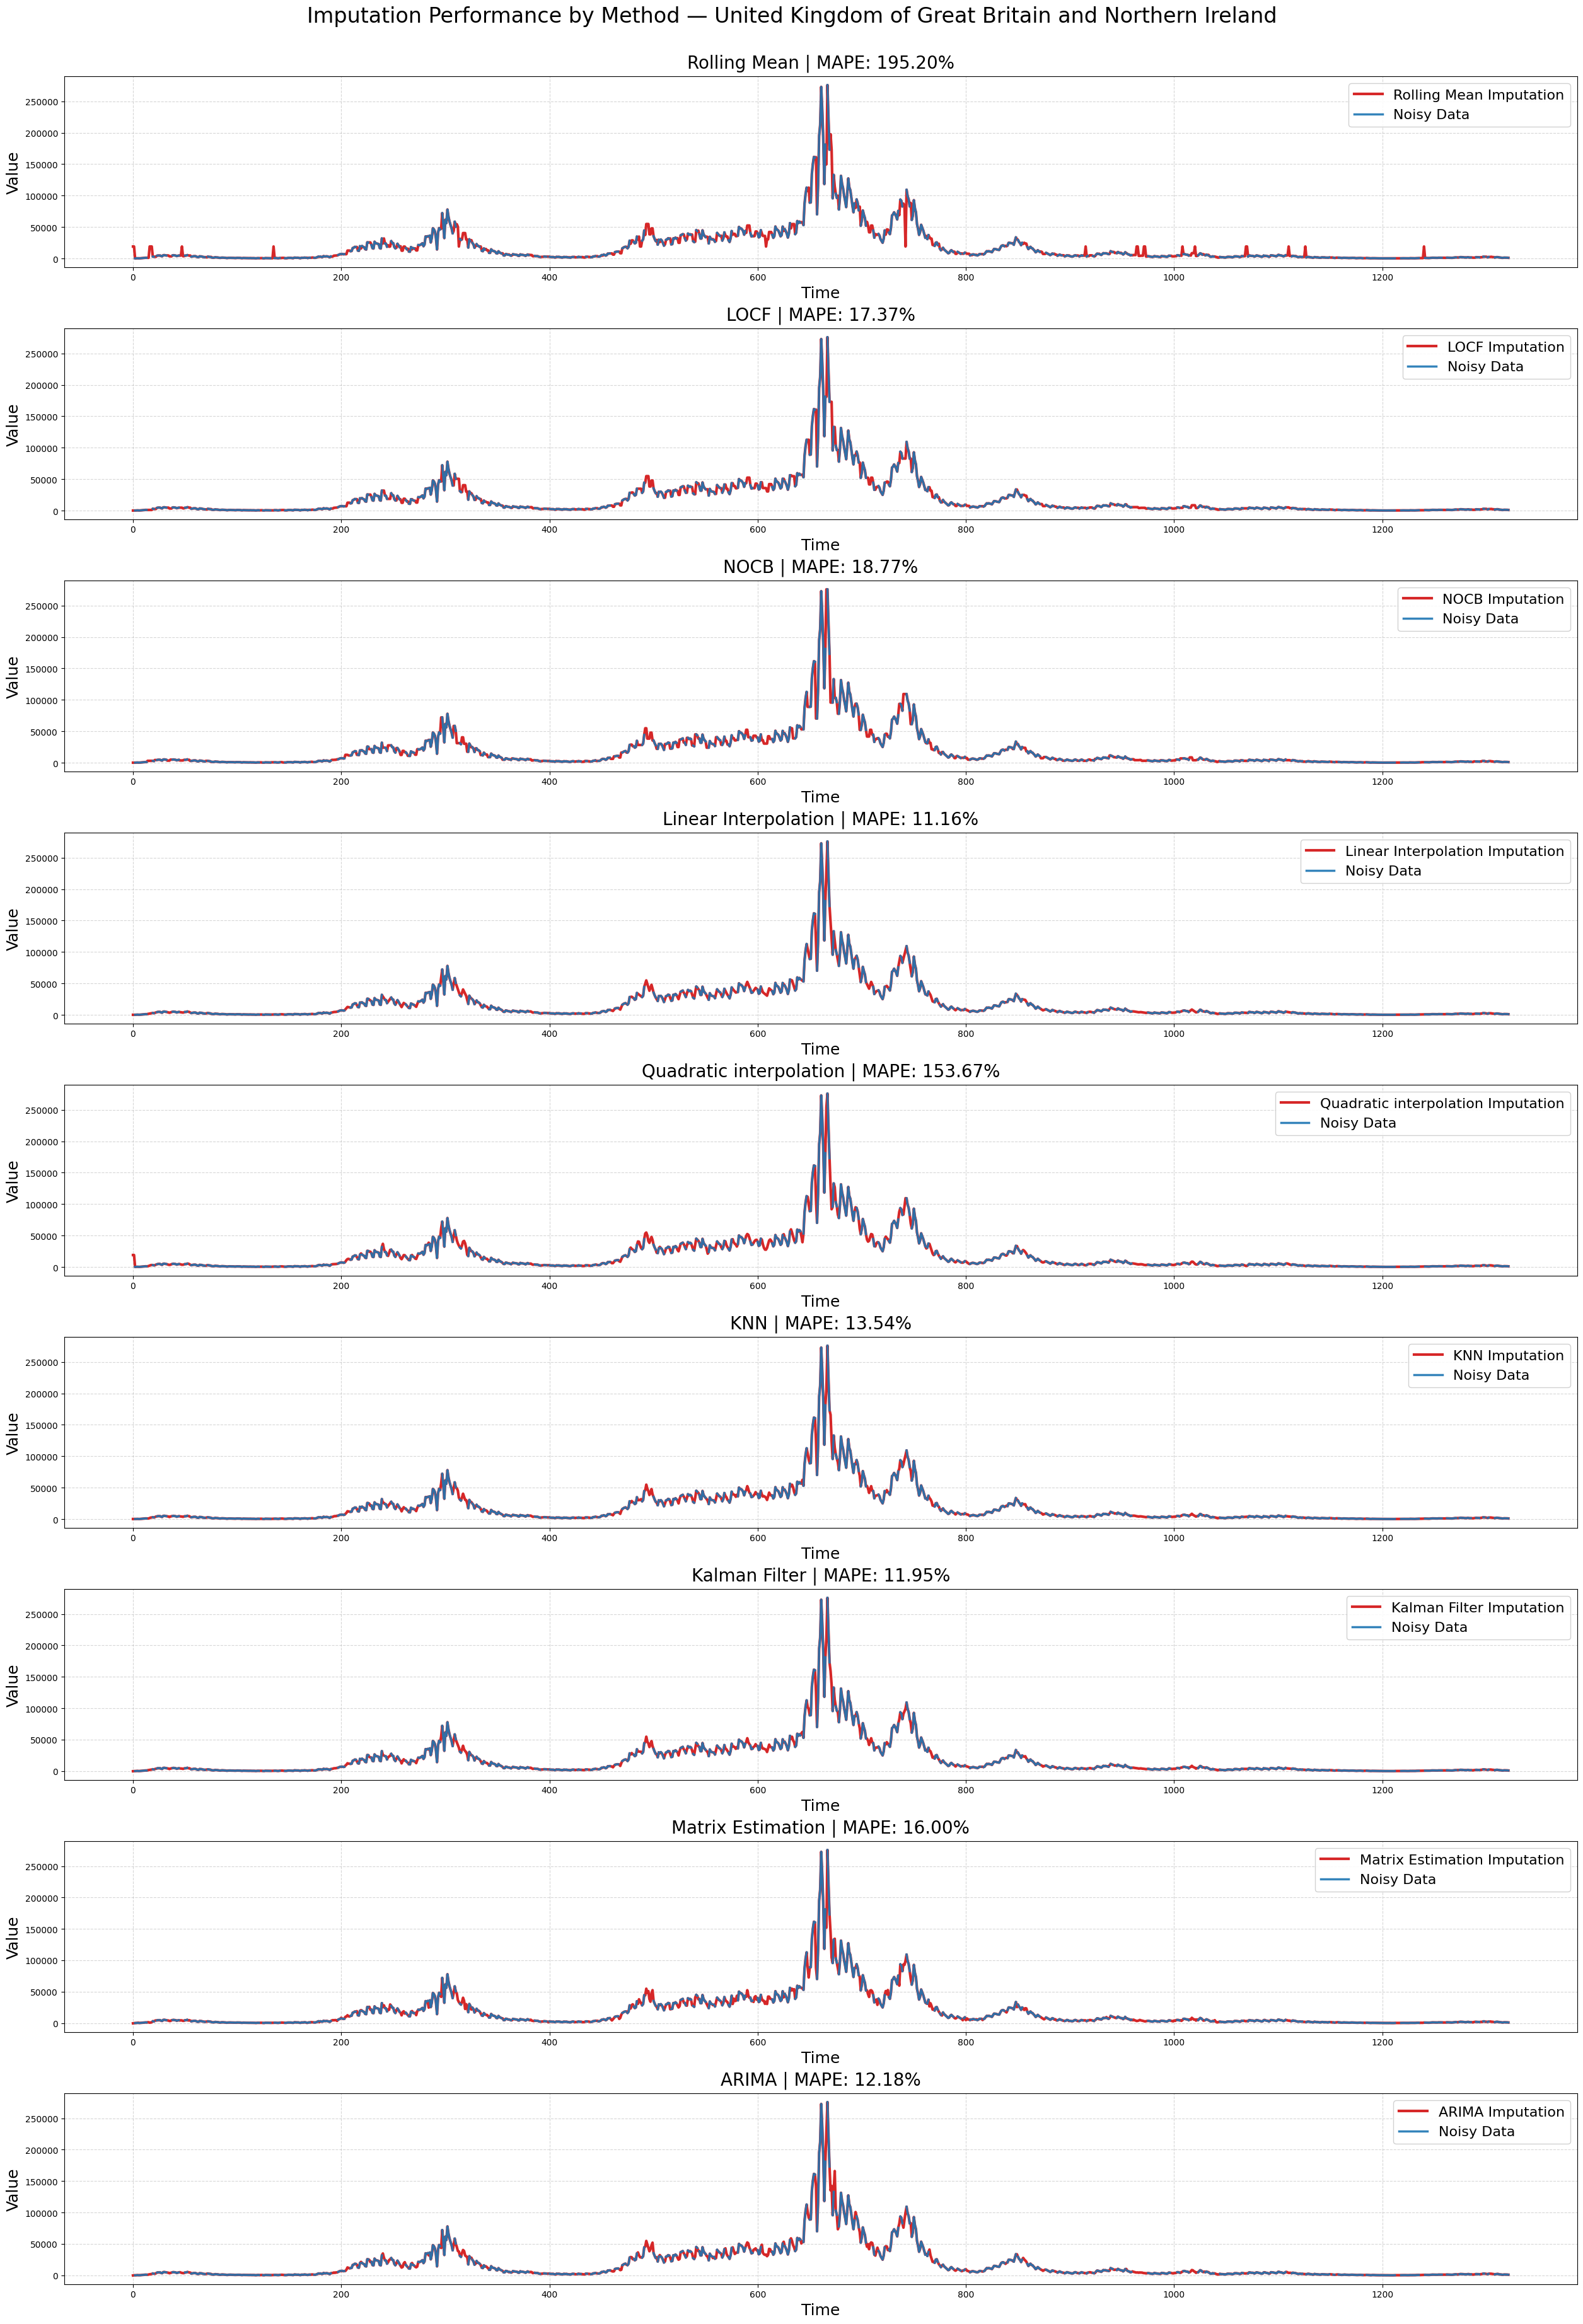

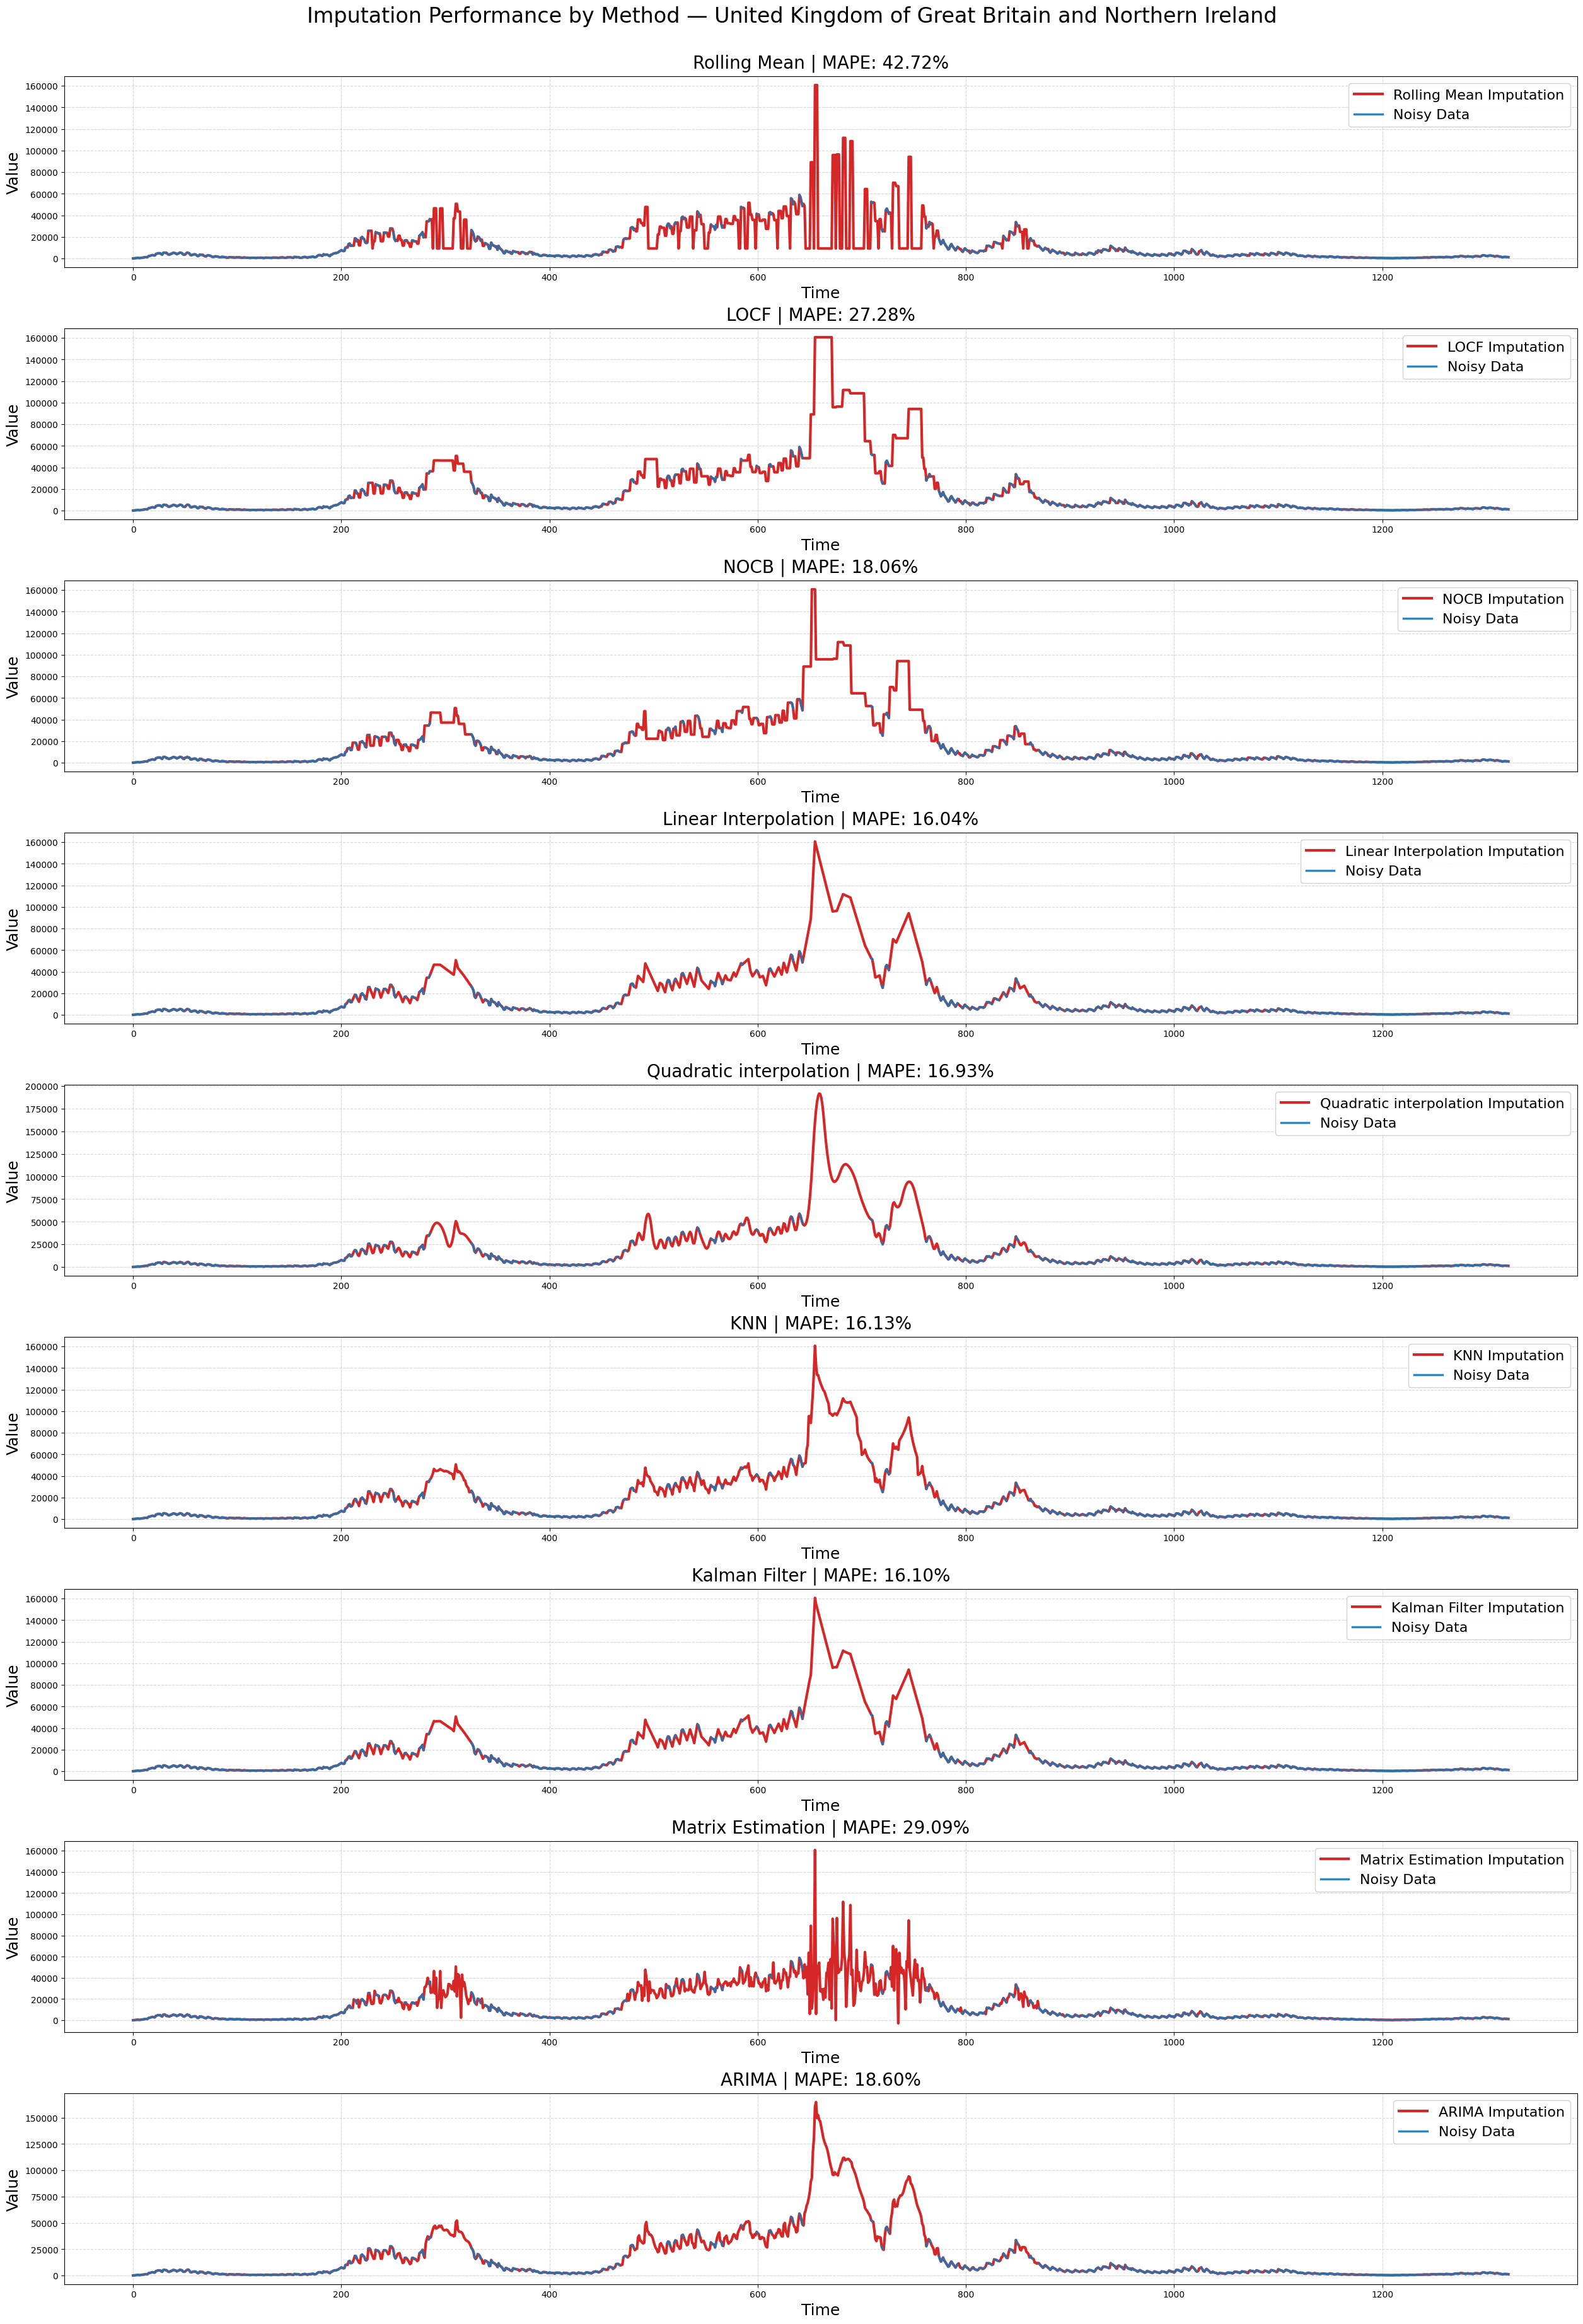

In [42]:
for nature in natures:
    print(f"THE {nature} NATURE")
    create_methods_performance_chart(countries_data['United Kingdom of Great Britain and Northern Ireland'], 
                                 'United Kingdom of Great Britain and Northern Ireland', 
                                 methods=methods, nature=nature)
